# Ship/Vessel Detection in Aerial Images using YOLOv8  
**Team Members:** Aragya Goyal and Olivia Sobek  
**Dataset:** [Link to Dataset](https://www.kaggle.com/datasets/siddharthkumarsah/ships-in-aerial-images)  
**Model:** YOLOv8m - Finetuned via transfer learning

## 1. Download Dataset from Kaggle

In [7]:
import kagglehub

dataset_path = kagglehub.dataset_download("siddharthkumarsah/ships-in-aerial-images")
print(f"Dataset downloaded to: {dataset_path}")

Dataset downloaded to: C:\Users\agoya\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1


## 2. Count images and labels

In [8]:
import os
from pathlib import Path

dataset_root = Path(dataset_path)

def find_dataset_root(base):
    """Walk downward to find the directory containing train/, valid/, test/."""
    base = Path(base)
    for dirpath, dirnames, _ in os.walk(base):
        subdirs = set(dirnames)
        if 'train' in subdirs and ('valid' in subdirs or 'val' in subdirs):
            return Path(dirpath)
    return base  # fallback

DS_ROOT = find_dataset_root(dataset_root)
print(f"Dataset root: {DS_ROOT}")
print(f"Contents: {os.listdir(DS_ROOT)}")

# Get number of images  and labels per split
print("Number of images and labels by split:")
for split in ['train', 'valid', 'test']:
    split_dir = DS_ROOT / split
    if not split_dir.exists():
        print(f"{split}: not found")
        continue
    img_dir = split_dir / 'images'
    lbl_dir = split_dir / 'labels'
    n_imgs = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
    n_lbls = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    print(f"{split:6s}: {n_imgs:5d} images, {n_lbls:5d} labels")

Dataset root: C:\Users\agoya\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images
Contents: ['data.yaml', 'data_yolov8.yaml', 'test', 'train', 'valid']
Number of images and labels by split:
train :  9697 images,  9697 labels
valid :  2165 images,  2165 labels
test  :  1573 images,  1573 labels


## 3. Random visualization

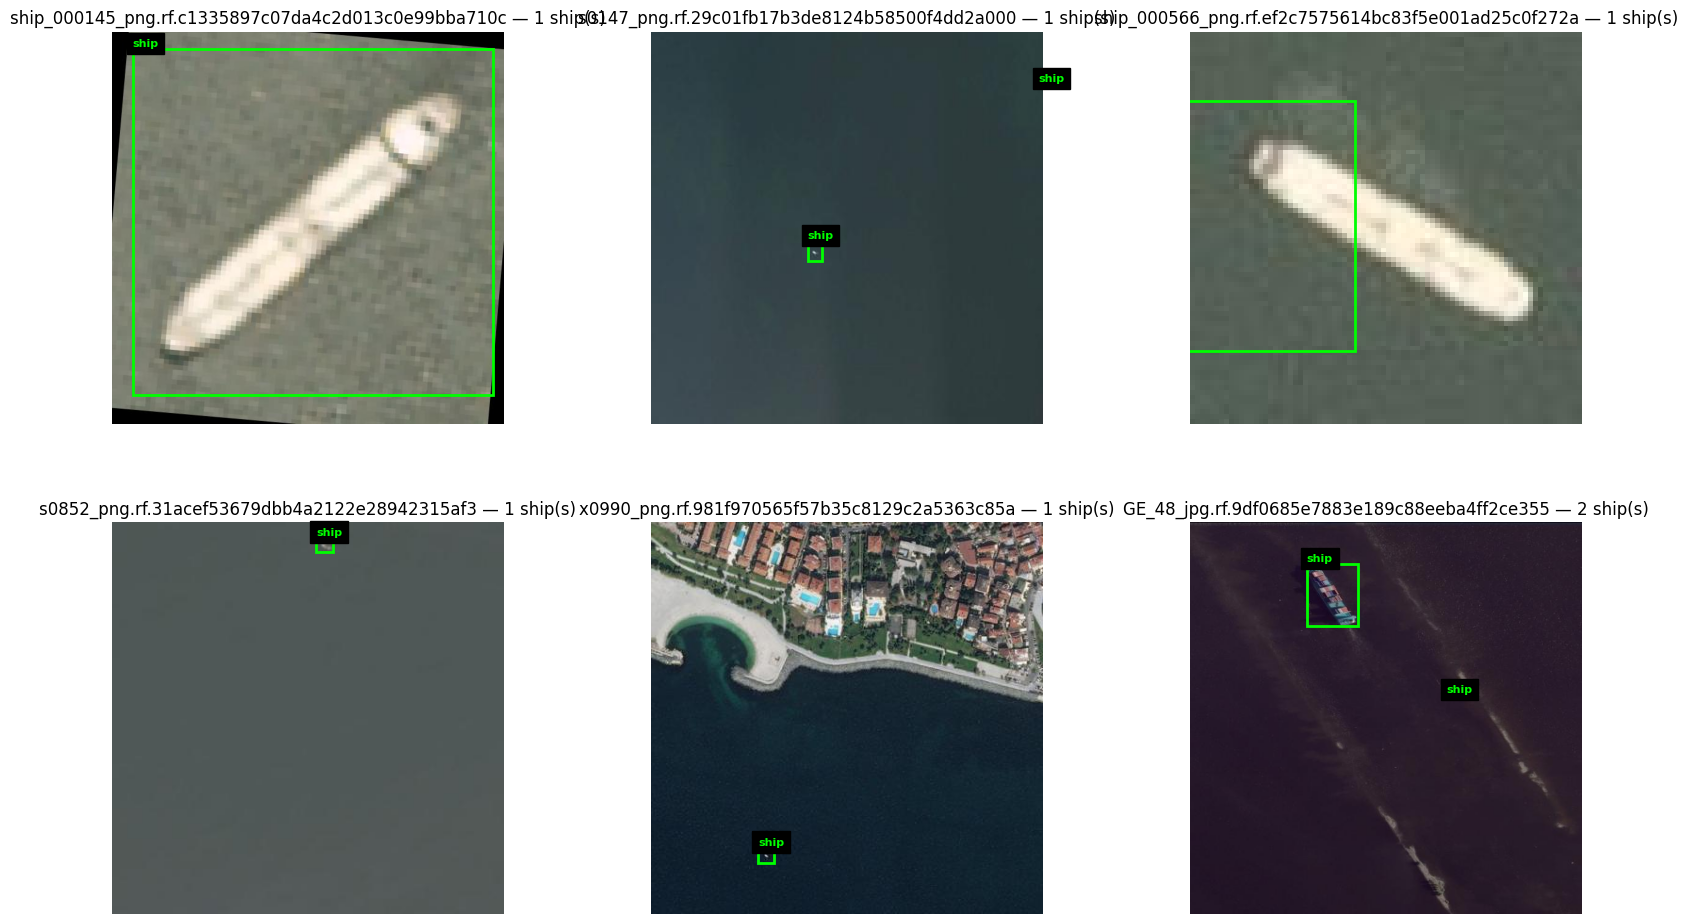

In [9]:
# Visualize sample training images with their YOLO bounding boxes
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

def plot_yolo_labels(img_path, lbl_path, ax, class_names=None):
    """Draw YOLO-format bounding boxes on an image."""
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().split('\n'):
            if not line.strip():
                continue
            parts = line.strip().split()
            cls_id = int(parts[0])
            xc, yc, bw, bh = [float(x) for x in parts[1:5]]
            # Convert normalized xywh -> pixel xyxy
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            box_w = bw * w
            box_h = bh * h
            rect = patches.Rectangle((x1, y1), box_w, box_h,
                                     linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            label = class_names[cls_id] if class_names else str(cls_id)
            ax.text(x1, y1 - 4, label, color='lime', fontsize=8,
                    fontweight='bold', backgroundcolor='black')
    ax.axis('off')

train_imgs = sorted((DS_ROOT / 'train' / 'images').glob('*'))
samples = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flat, samples):
    lbl_path = DS_ROOT / 'train' / 'labels' / (img_path.stem + '.txt')
    plot_yolo_labels(img_path, lbl_path, ax, class_names=['ship'])
    n_objs = len(lbl_path.read_text().strip().split('\n')) if lbl_path.exists() else 0
    ax.set_title(f"{img_path.stem} — {n_objs} ship(s)")

plt.tight_layout()
plt.show()

## 4. Prep data.yaml

In [10]:
import yaml

# Read class info from the dataset's yaml
with open(DS_ROOT / 'data.yaml') as f:
    cfg = yaml.safe_load(f)

names = cfg['names']
if isinstance(names, dict):
    names = [names[i] for i in sorted(names)]

print(f"Classes: {names}")

# Rewrite yaml with absolute paths
yaml_path = DS_ROOT / 'data_yolov8.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump({
        'path': str(DS_ROOT.resolve()),
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'nc': len(names),
        'names': names,
    }, f)

print(yaml_path.read_text())

Classes: ['ship']
names:
- ship
nc: 1
path: C:\Users\agoya\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images
test: test/images
train: train/images
val: valid/images



## 5. Finetune pretrained YOLO model

In [11]:
# Check GPU or CPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [12]:
from ultralytics import YOLO

# Load pretrained model — can use 'yolov8n.pt', 'yolov8s.pt', or 'yolov8m.pt'
model = YOLO('yolov8s.pt')

# Finetune
results = model.train(
    # Training Parameters
    data=str(yaml_path),
    warmup_epochs=3,        # Helps update initial learning rate
    epochs=100,             # Epochs for training
    imgsz=640,              # Resizing image before feeding to model - higher = easier detection, lower = faster training, harder detections
    batch=16,               # number images processed at a time, bigger = faster training but requires more resources
    patience=10,            # early stopping in case of not enough improvemnet across epochs
    
    # Saving and logging
    save=True,                      # Save checkpoints
    project='runs/ship_detect',
    name='yolov8s_finetune',
    exist_ok=True,
    pretrained=True,                # Use pretrained weights
    optimizer='auto'

    # Augmentations tuned for imagery to prevent overfitting
    flipud=0.5,             # vertical flip
    fliplr=0.5,             # horizontal flip
    mosaic=1.0,             # mosaic augmentation
    degrees=15.0,           # small rotation
    scale=0.5,              # scale jitter
    hsv_h=0.015,            # Shift hue
    hsv_s=0.7,              # Shift saturation
    hsv_v=0.4,              # Shift brightness
)

New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.12.10 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\agoya\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\data_yolov8.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ra

## 6. Model Evaluation